In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

# Visualizing the eigenvalues from empirical observability gramian

In [6]:
try:
    eig_values = np.load("../scripts/variables/eig_values_01.npy")
except Exception:
    print("Run 01_Observability_Analysis.py")

In [7]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)

curr_module = "01"
num_patients = cfg[curr_module]["num_patients"]
threshold = cfg[curr_module]["threshold"]
percent_states_over_threshold = np.sum(eig_values > threshold) / len(eig_values)
print("Percent of eigenvalues over threshold: ", percent_states_over_threshold)

Percent of eigenvalues over threshold:  1.223


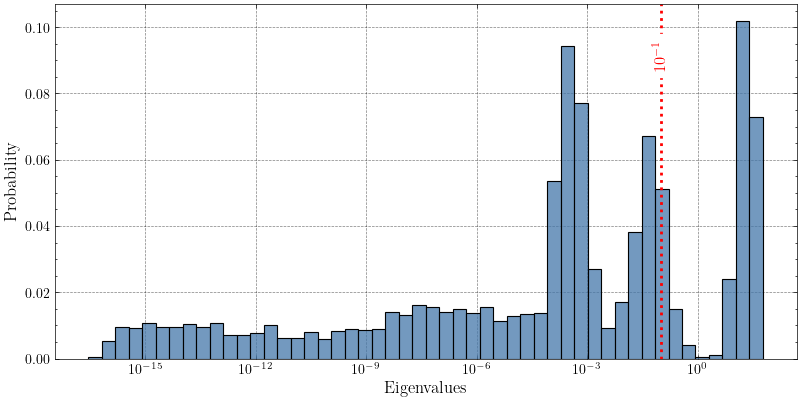

In [8]:
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(
    eig_values.flatten(),
    stat="probability",
    bins=50,
    ax=ax,
    log_scale=True,
    legend=False,
    kde=False,
)
ax.axvline(threshold, color="red", linestyle=":", linewidth=2)
ax.text(
    threshold,
    ax.get_ylim()[1] * 0.90,
    r"$10^{-1}$",
    color="red",
    rotation=90,
    va="top",
    ha="center",
    backgroundcolor="white",
)
ax.set_xlabel("Eigenvalues")
fig.savefig("figures/5_3.pdf", format="pdf")